In [1]:
import numpy as np
import numba
from numba import jit #jit complier

In [2]:
import gzip
import json
import string
import re

import numpy as np                                                               
import matplotlib.pyplot as plt

#import nltk # imports the natural language toolkit
import pandas as pd
import plotly

from collections import Counter
from datetime import datetime
#from sklearn.feature_extraction.text import CountVectorizer

from IPython.display import display

#nltk.download('punkt')

A continuacion cargamos la base de datos que muestra unas reviews hacia un restaurante con su debida calificacion

In [3]:
import pandas as pd

# Leer todo el archivo CSV
df = pd.read_csv('reviews.csv')




Vamos a revisar las columnas con las que cuenta nuestra base de datos para hacer la limpieza correspondiente, ver si tienen nulos y coger solo las que nos interese para nuestra investigacionl.

In [4]:
df.head(2)

,id_review,review,title,score,likes,id_nick,service,date,platform,pre_review,...,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,negative,positive
0,R100000,"Nos encant��! !! Delicioso, excelente atenci��...",Muy buena,5,0,33carlab,40012,7 years ago,tripadvisor,encant � � delicia excelente atenci � � n siti...,...,0.136364,0.090909,0.090909,0.090909,0.136364,0.227273,0.136364,0.090909,0.571429,0.428571
1,R1000003,Se come bien parrillas,NaN,5,0,116683193740858649916,265714,4 years ago,googleplaces,comer parrilla,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.500000


In [5]:

# Contar los valores nulos en cada columna
null_counts = df.isnull().sum()

# Mostrar las columnas que tienen valores nulos
print(null_counts[null_counts > 0])

title         433372
pre_review      1511
dtype: int64


Al revisar las columnas disponibles, consideramos necesario tener en cuenta las siguientes: review, score, date y platform

In [6]:
import pandas as pd

# Leer todo el archivo CSV
df = pd.read_csv('reviews.csv')

# Seleccionar solo las columnas necesarias
columnas_necesarias = ['review', 'score', 'date', 'platform']
df = df[columnas_necesarias]

df


,review,score,date,platform
0,"Nos encant��! !! Delicioso, excelente atenci��...",5,7 years ago,tripadvisor
1,Se come bien parrillas,5,4 years ago,googleplaces
2,Los muñequitos o,3,12 months ago,googleplaces
3,Una pollería más,3,3 years ago,googleplaces
4,La comida es buena de eso nadie lo duda pero e...,3,7 years ago,tripadvisor
...,...,...,...,...
497344,Arreglen sus baños y completarian sus 5 estrellas,4,3 years ago,googleplaces
497345,este restaurante no tiene una carta muy grande...,5,7 years ago,tripadvisor
497346,"Bueno, Rico, Ubicuo,",5,2 years ago,googleplaces
497347,Por mejorar la Atencion al cliente,3,3 years ago,googleplaces


Para analizar mejor el conjunto de datos se revisan las frecuencias de ocurrencia de estas evaluaciones, es decir cuales son las proporciones de calificaciones en cada escala.

In [7]:
frecuencias = df[['review', 'score']].groupby(['score']).count()
frecuencias


,review
score,
1,28942
2,21724
3,63716
4,144188
5,238779


Realizando una gráfica de barras de las frecuencias de ocurrencia, podemos ver con mayor facilidad la proporción de cada una de las calificaciones

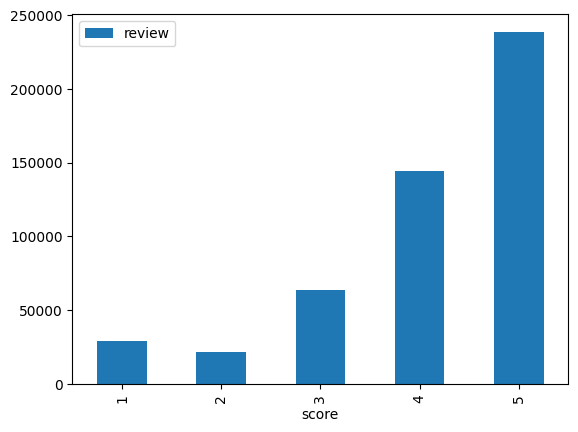

In [8]:
ax = frecuencias.plot.bar(column = ['overall'])


La gráfica sugiere que los usuarios tienden a dar puntuaciones altas en sus reseñas, con una clara mayoría en la puntuación máxima de 5. Esto podría ser útil para entender la percepción general de los usuarios sobre los restaurantes

In [9]:
df.insert(loc=2, column= 'reviewlen', value= df['review'].str.len() )
df.head()


,review,score,reviewlen,date,platform
0,"Nos encant��! !! Delicioso, excelente atenci��...",5,119,7 years ago,tripadvisor
1,Se come bien parrillas,5,22,4 years ago,googleplaces
2,Los muñequitos o,3,16,12 months ago,googleplaces
3,Una pollería más,3,16,3 years ago,googleplaces
4,La comida es buena de eso nadie lo duda pero e...,3,169,7 years ago,tripadvisor


In [10]:
#First part, classify reviews as positive if the overall rating is > 3 and negative otherwise
def tag_positive_negative_by_score(element):
    if float(element['overall']) > 3:
        element['review_sentiment'] = 'positive'
    else:
        element['review_sentiment'] = 'negative'
    return element

## Analisis NLP

En este ejercicio en particular comenzaremos con un proceso de Tokenización, y posteriormente identificaremos las palabras definidas como stop words en español para eliminarlas del análisis.

In [11]:
#loading libraries

from nltk.corpus import stopwords 
from nltk.tokenize import RegexpTokenizer
from functools import partial

Tambien al tener una gran cantidad de registros se va realizar la maquina de paralelo para llevar a cabo mas rapido la ejecucion de todos los datos ya que con el cliente Dask se obtiene:

Gestiona los recursos de cómputo:distribuyendo las tareas entre los trabajadores disponibles.   

Paralelización: Permite ejecutar tareas en paralelo, lo que puede acelerar significativamente el procesamiento de grandes conjuntos de datos.

Monitoreo: Proporciona herramientas para monitorear el estado y el rendimiento de las tareas en ejecución.

In [12]:
import dask.dataframe as dd
from dask.diagnostics import ProgressBar 
from dask.distributed import Client, progress
import dask.bag as db

In [13]:
client = Client(n_workers=4, threads_per_worker=4, processes=False, memory_limit='4GB')
client

c:\Users\juane\miniconda3\envs\computacion_paralelo\Lib\site-packages\distributed\node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 52768 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://192.168.1.9:52768/status,
Dashboard: http://192.168.1.9:52768/status,Workers: 4
Total threads: 16,Total memory: 14.90 GiB
Status: running,Using processes: False
Comm: inproc://192.168.1.9/25548/1,Workers: 4
Dashboard: http://192.168.1.9:52768/status,Total threads: 16
Started: Just now,Total memory: 14.90 GiB
Comm: inproc://192.168.1.9/25548/4,Total threads: 4
Dashboard: http://192.168.1.9:52769/status,Memory: 3.73 GiB
Nanny: None,



-Lo primero que debemos hacer para realizar un análisis de NLP es un proceso de Tokenización, es decir, separar las oraciones en palabras. Para esto usaremos el método RegexpTokenizer de nltk y el uso de Regex (Expresiones regulares).



In [14]:
# Functions to process the reviews

tokenizer = RegexpTokenizer(r'\w+')
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

# Obtener las stopwords en español
stopwords = stopwords.words('spanish')
print(stopwords)

['de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las', 'por', 'un', 'para', 'con', 'no', 'una', 'su', 'al', 'lo', 'como', 'más', 'pero', 'sus', 'le', 'ya', 'o', 'este', 'sí', 'porque', 'esta', 'entre', 'cuando', 'muy', 'sin', 'sobre', 'también', 'me', 'hasta', 'hay', 'donde', 'quien', 'desde', 'todo', 'nos', 'durante', 'todos', 'uno', 'les', 'ni', 'contra', 'otros', 'ese', 'eso', 'ante', 'ellos', 'e', 'esto', 'mí', 'antes', 'algunos', 'qué', 'unos', 'yo', 'otro', 'otras', 'otra', 'él', 'tanto', 'esa', 'estos', 'mucho', 'quienes', 'nada', 'muchos', 'cual', 'poco', 'ella', 'estar', 'estas', 'algunas', 'algo', 'nosotros', 'mi', 'mis', 'tú', 'te', 'ti', 'tu', 'tus', 'ellas', 'nosotras', 'vosotros', 'vosotras', 'os', 'mío', 'mía', 'míos', 'mías', 'tuyo', 'tuya', 'tuyos', 'tuyas', 'suyo', 'suya', 'suyos', 'suyas', 'nuestro', 'nuestra', 'nuestros', 'nuestras', 'vuestro', 'vuestra', 'vuestros', 'vuestras', 'esos', 'esas', 'estoy', 'estás', 'está', 'estamos', 'estáis', 'están', 'e

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\juane\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Funciones para procesar los reviews

In [15]:

def extract_reviews(bagtoprocess):
    return bagtoprocess.lower()
                            
def checkif_stopword(word, stopwords):
    return word not in stopwords

def filter_stopwords(tokens, stopwords):
    return list(filter(partial(checkif_stopword, stopwords=stopwords), tokens))
            

Usando las funciones previamente definidas realizamos el proceso de tokenización y eliminación de stop words para cada reseña realizada por los usuarios.

In [16]:
texto_critica = df['review'].squeeze() #convertir en una serie de Python
texto_critica_minusculas = texto_critica.map(extract_reviews) #all text in lower
texto_tokens = texto_critica_minusculas.map(tokenizer.tokenize) #just words
texto_limpio = texto_tokens.map(partial(filter_stopwords, stopwords=stopwords)) #filtering spanish stopwords

In [17]:
print(texto_limpio.head())
print(len(texto_limpio))

0    [encant, delicioso, excelente, atenci, n, siti...
1                              [come, bien, parrillas]
2                                         [muñequitos]
3                                           [pollería]
4    [comida, buena, nadie, duda, espació, chico, s...
Name: review, dtype: object
497349


In [18]:
print(texto_critica[0], '\n')
print(texto_limpio[0])

Nos encant��! !! Delicioso, excelente atenci��n y el sitio precioso y decorado con muy buen gusto!!! No se la pierdan!! 

['encant', 'delicioso', 'excelente', 'atenci', 'n', 'sitio', 'precioso', 'decorado', 'buen', 'gusto', 'pierdan']


Teniendo en cuenta el objetivo (comparar entre comentarios positivos y negativos), y ahora que conocemos el concepto de tokenización, nos vamos a apoyar en la **librería de sklearn** de extracción de texto y la función **CountVectorizer**, que básicamente realiza el contenido de los tokens (palabras) para una serie de textos, en este caso, la columna que contiene los comentarios de los usuarios.

In [19]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Obtener las stopwords en español
stop_words_es = stopwords.words('spanish')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\juane\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


La primera dificultad que encontré fue que sklearn no tiene stopwords en español. Por lo tanto, no pude especificar “spanish” en la entrada de CountVectorizer, ya que no lo reconocía. Para solucionar esto, tuve que agregar manualmente las stopwords en español y asignárselas a CountVectorizer para poder ejecutar la función correctamente.

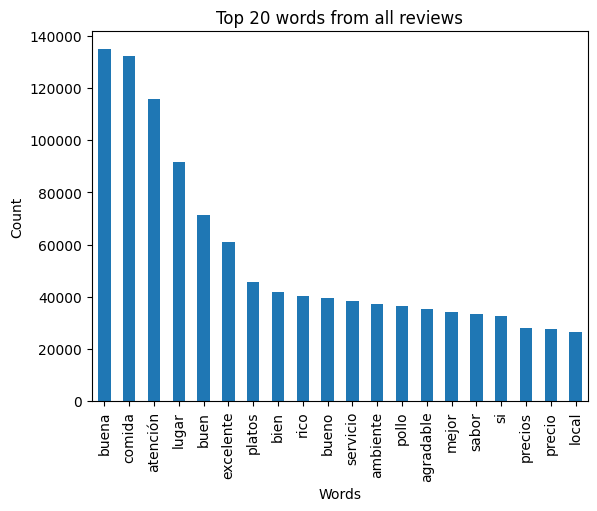

In [20]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt

# Función para obtener las palabras más frecuentes
def get_top_n_words(corpus, n=1, k=1):
    vec = CountVectorizer(ngram_range=(k, k), stop_words=stop_words_es)
    bag_of_words = vec.fit_transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# Obtener las palabras más comunes
common_words = get_top_n_words(df["review"], 20, 1)

# Crear un DataFrame con las palabras y sus frecuencias
df_top_words = pd.DataFrame(common_words, columns=["words", "count"])

# Generar el gráfico de barras
df_top_words.groupby("words").sum()["count"].sort_values(ascending=False).plot(
    kind="bar", title="Top 20 words from all reviews"
)
plt.xlabel("Words")
plt.ylabel("Count")
plt.show()


Aqui encontramos las 20 palabras mas utilizadas en todos los reviews.

Ahora vamos a separar nuestro conjunto de datos, de acuerdo a un nuevo criterio definido de comentarios positivos con una calificación mayor a 3 y negativos con calificación inferior a 2.1

In [21]:

# Comentarios positivos
good_indices = df["score"] > 3.1
good_reviews = df[good_indices]
bad_indices = df["score"] < 2.1
bad_reviews = df[bad_indices]


Ahora realizamos un proceso similar de cálculo de frecuencia de palabras, solamente en los reviews que consideramos positivos.

In [22]:

common_words = get_top_n_words(good_reviews["review"], 20)
for word, freq in common_words:
    print(word, freq)



buena 115069
comida 103598
atención 90097
lugar 76005
buen 62520
excelente 58811
platos 36261
rico 34647
ambiente 32273
bien 31539
bueno 30925
agradable 28825
servicio 28603
mejor 27798
pollo 25717
sabor 22043
precios 21621
si 20693
precio 20176
recomiendo 19508


<Axes: title={'center': 'Top 20 words from good reviews'}, xlabel='words'>

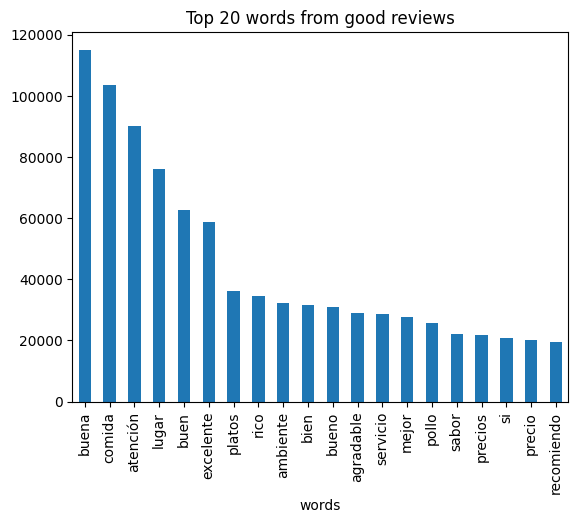

In [23]:

df_positive = pd.DataFrame(common_words, columns=["words", 'count'])
df_positive.groupby('words').sum()['count'].sort_values(ascending=False).plot(
    kind='bar', title='Top 20 words from good reviews'
)

En las reseñas positivas del restaurante, se destaca principalmente la calidad general, ya que la palabra “buena” es la más mencionada. Esto sugiere que los clientes están satisfechos con su experiencia en general. La segunda palabra más frecuente es “comida”, lo que indica que la calidad de los alimentos es un factor crucial para los clientes.

Además, términos como “lugar” y “atención” también aparecen con alta frecuencia, lo que resalta la importancia del ambiente y el servicio al cliente. Un buen lugar y una atención excelente son aspectos fundamentales que contribuyen a una experiencia positiva.

Aunque el “precio” no es una de las palabras más mencionadas, sigue siendo un factor a considerar. Esto sugiere que, aunque los clientes valoran más la calidad de la comida y el servicio, el precio también juega un papel en su satisfacción general.

En resumen, para mantener y mejorar las reseñas positivas, el restaurante debe enfocarse en mantener la alta calidad de la comida, ofrecer un ambiente agradable y proporcionar un excelente servicio al cliente. El precio, aunque menos mencionado, también debe ser competitivo para asegurar una experiencia completa y satisfactoria para los clientes.

Realizamos un proceso similar para los reviews negativos. Es interesante observar que la palabra good sigue siendo representativa.

atención 12097
comida 11827
mala 5828
lugar 5660
sabor 5607
si 5593
pollo 5573
servicio 5162
buena 4812
mal 4383
local 3858
calidad 3854
platos 3627
pedido 3566
solo 3485
bien 3183
pésima 3178
precio 2858
plato 2786
restaurante 2694


<Axes: title={'center': 'Top 20 words from bad reviews'}, xlabel='words'>

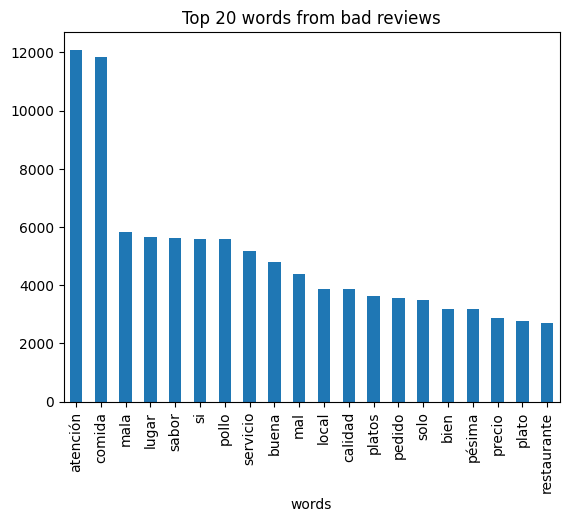

In [24]:
# Comentarios negativos
common_words = get_top_n_words(bad_reviews['review'], 20)
for word, freq in common_words:
    print(word, freq)
df_negative = pd.DataFrame(common_words, columns=['words', 'count'])
df_negative.groupby('words').sum()['count'].sort_values(ascending=False).plot(
    kind='bar', title='Top 20 words from bad reviews'
)

En las reseñas negativas del restaurante, se destacan varios aspectos que los clientes consideran insatisfactorios. La palabra más mencionada es “lugar”, lo que sugiere que muchos clientes tienen quejas sobre el ambiente o la ubicación del restaurante.

La segunda palabra más frecuente es “atención”, indicando que el servicio al cliente es un área de preocupación significativa. La calidad de la “comida” también aparece como una queja común, lo que resalta la importancia de mantener altos estándares en los alimentos ofrecidos.

Otros términos como “servicio” y “mala” también son recurrentes, subrayando problemas generales con la experiencia del cliente. Palabras como “precio” y “calidad” sugieren que algunos clientes sienten que no están recibiendo un buen valor por su dinero.

En resumen, para abordar las reseñas negativas, el restaurante debería enfocarse en mejorar el ambiente, la atención al cliente y la calidad de la comida. Además, aunque el precio no es la queja más frecuente, sigue siendo un factor a considerar para mejorar la percepción general de los clientes

Esto nos ayuda mucho aunque seria de gran interés es detectar palabras que están en los reviews negativos y que normalmente no se encuentran en los reviews positivos.

Para esto construimos una función que calcule las 20 palabras con frecuencia mas alta, que estén en reviews negativos

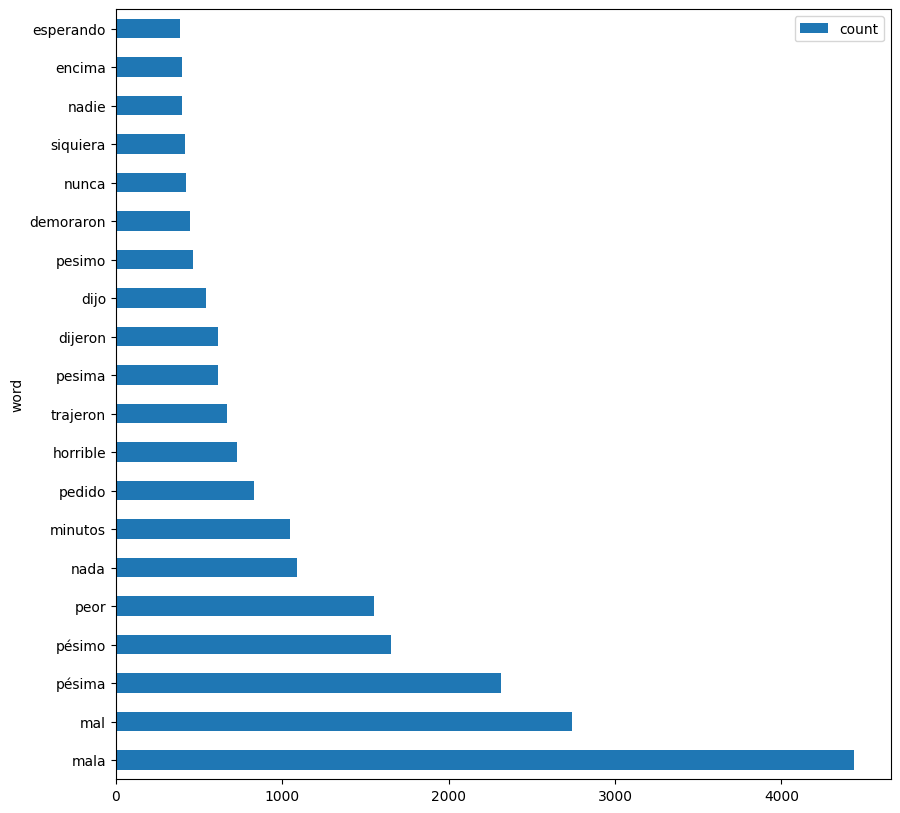

In [25]:
from collections import Counter
# https://docs.python.org/3/library/collections.html

def get_indicative_words(text1, text2, n=20):
    c1 = Counter(text1.lower().split(" "))
    c2 = Counter(text2.lower().split(" "))
    ind_words_1 = (c1 - c2).most_common(n) #most_common, método de la clase Counter
    ind_words_2 = (c2 - c1).most_common(n)    
    x, y = zip(*ind_words_2)
    #https://www.programiz.com/python-programming/methods/built-in/zip
    df_indicative = pd.DataFrame({'word': x, 'count': y})
    df_indicative.plot.barh(
        x='word', y='count', figsize=(10,10)
    )
    return(c1)

c1 = get_indicative_words(' '.join(good_reviews['review']), ' '.join(bad_reviews['review']))

Ya teniendo en cuenta solo las que aparecen en negativo se puede hacer el siguiente analisis: 

Tiempo de espera: Palabras como “demoraron” y “minutos” sugieren que los clientes están frustrados con los tiempos de espera largos.

Calidad del servicio/producto: Términos como “pésimo”, “horrible”, “peor”, “mal”, y “mala” indican que los usuarios están muy insatisfechos con la calidad del servicio o producto recibido.

Comunicación: Palabras como “dijo” y “dijeron” pueden implicar problemas de comunicación o malentendidos entre el cliente y el proveedor del servicio.

Impacto emocional:
Palabras como “nunca”, “nada”, y “nadie” reflejan una sensación de decepción y desesperanza, lo que puede tener un impacto negativo significativo en la percepción de la marca.

## Correlacion de palabras y Biagramas

Ahora que hemos identificado las palabras más utilizadas en las reseñas negativas y positivas, podemos profundizar en el análisis calculando la correlación entre la frecuencia de las palabras que aparecen juntas más comúnmente y las calificaciones de las reseñas. Este enfoque nos permitirá entender mejor cómo ciertos términos y combinaciones de palabras influyen en las calificaciones negativas como a su vz las postivas para sugerirle lo mejor al restaurante para tener las mejores calificaciones.

In [32]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from dask import delayed, compute
from dask.dataframe import from_pandas
from dask.distributed import Client

# Conectar con el clúster Dask
client = Client(n_workers=4, threads_per_worker=2, memory_limit='4GB')


# Definir los stopwords en español (asegúrate de definir `stop_words_es`)
stop_words_es = stopwords.words('spanish')



def get_top_n_bigrams(corpus, n=10):
    vec = CountVectorizer(ngram_range=(2, 2), stop_words=stop_words_es)
    bag_of_words = vec.fit_transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    bigrams_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    bigrams_freq = sorted(bigrams_freq, key=lambda x: x[1], reverse=True)
    return bigrams_freq[:n]

def create_bigram_matrix(df, bigram_vocab):
    count_vect = CountVectorizer(ngram_range=(2, 2), vocabulary=bigram_vocab, stop_words=stop_words_es)
    bigram_counts = count_vect.fit_transform(df['processed_text'])
    bigram_freq_df = pd.DataFrame(bigram_counts.toarray(), columns=count_vect.get_feature_names_out())
    bigram_freq_df['score'] = df['score']
    return bigram_freq_df


def calculate_correlations(bigram_freq_df, df_top_bigrams):
    correlations = bigram_freq_df.corr()['score'].sort_values(ascending=False)
    df_top_bigrams['correlation'] = df_top_bigrams['bigram'].map(correlations)
    return df_top_bigrams

# Crear un DataFrame de Dask desde el DataFrame original
df_dask = from_pandas(df, npartitions=4)

# Preprocesar el texto de las reseñas
df_dask['processed_text'] = df_dask['review']

# Obtener los bigramas más comunes
common_bigrams = get_top_n_bigrams(df_dask['processed_text'].compute(), 20)

# Crear un DataFrame con los bigramas y sus frecuencias
df_top_bigrams = pd.DataFrame(common_bigrams, columns=["bigram", "count"])

# Crear una matriz de términos con los bigramas más comunes
bigram_matrix_task = create_bigram_matrix(df_dask, df_top_bigrams['bigram'].tolist())

# Calcular las correlaciones
df_top_bigrams_task = calculate_correlations(bigram_matrix_task, df_top_bigrams)

# Ejecutar tareas
df_top_bigrams_result = compute(df_top_bigrams_task)

# Mostrar el DataFrame resultante con bigramas, frecuencia y correlación
print(df_top_bigrams_result)


c:\Users\juane\miniconda3\envs\computacion_paralelo\Lib\site-packages\distributed\node.py:182: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 53282 instead
  warnings.warn(
c:\Users\juane\miniconda3\envs\computacion_paralelo\Lib\contextlib.py:144: UserWarning: Creating scratch directories is taking a surprisingly long time. (1.21s) This is often due to running workers on a network file system. Consider specifying a local-directory to point workers to write scratch data to a local disk.
  next(self.gen)
c:\Users\juane\miniconda3\envs\computacion_paralelo\Lib\site-packages\distributed\client.py:3362: UserWarning: Sending large graph of size 59.44 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  w

(                bigram  count  correlation
0       buena atención  36808     0.090084
1         buena comida  22782     0.049255
2           buen lugar  16721     0.042948
3         comida buena  12536    -0.006249
4       atención buena  12101     0.019600
5        buen servicio   8436     0.041425
6   excelente atención   8411     0.081594
7          pollo brasa   7831     0.010293
8        buen ambiente   7522     0.035944
9      excelente lugar   7350     0.074763
10          buen sabor   7302     0.004114
11      buena atencion   6592     0.036288
12         comida rica   6431     0.011689
13    excelente comida   5907     0.063955
14           vale pena   5864     0.018997
15  ambiente agradable   5382     0.026166
16         buen precio   5072     0.032318
17     atención rápida   5062     0.020681
18    comida deliciosa   4878     0.051242
19     variedad platos   4803     0.016617,)


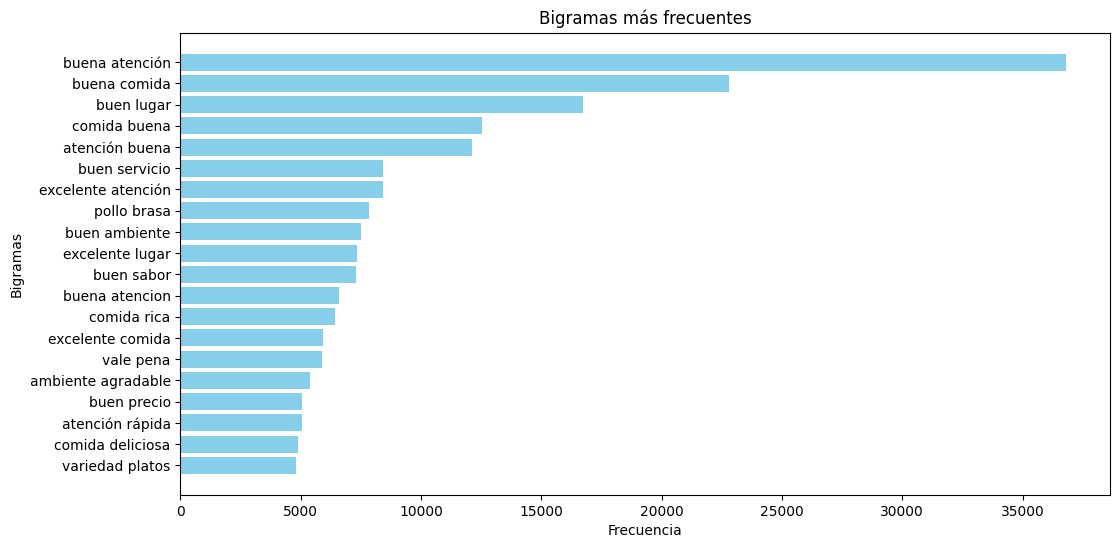

In [59]:
import matplotlib.pyplot as plt

# Crear un gráfico de barras para visualizar los bigramas más frecuentes
plt.figure(figsize=(12, 6))
plt.barh(df_top_bigrams['bigram'], df_top_bigrams['count'], color='skyblue')
plt.xlabel('Frecuencia')
plt.ylabel('Bigramas')
plt.title('Bigramas más frecuentes')
plt.gca().invert_yaxis()  # Invertir el eje y para que el bigrama más frecuente esté en la parte superior
plt.show()


Lo que mas destaca en las reseñas es lo siguiente 

Buena Atención y Comida:Las reseñas destacan principalmente la buena atención y la buena comida del restaurante, lo que indica que estos son los puntos fuertes más valorados por los clientes.
La frecuencia de bigramas como “buena atención” y “buena comida” refuerza esta percepción positiva.

Calidad del Servicio:
La atención y el servicio son mencionados repetidamente en las reseñas, lo que sugiere que los clientes valoran mucho la calidad del servicio recibido.
Bigrams como “excelente atención” y “buen servicio” son comunes, lo que subraya la importancia de un servicio al cliente excepcional.

Plato Insignia:
El “pollo a la brasa” se menciona frecuentemente, lo que indica que es uno de los platos más populares y apreciados por los clientes.
La alta frecuencia de este bigrama sugiere que este plato es un elemento clave del menú que atrae a muchos clientes.

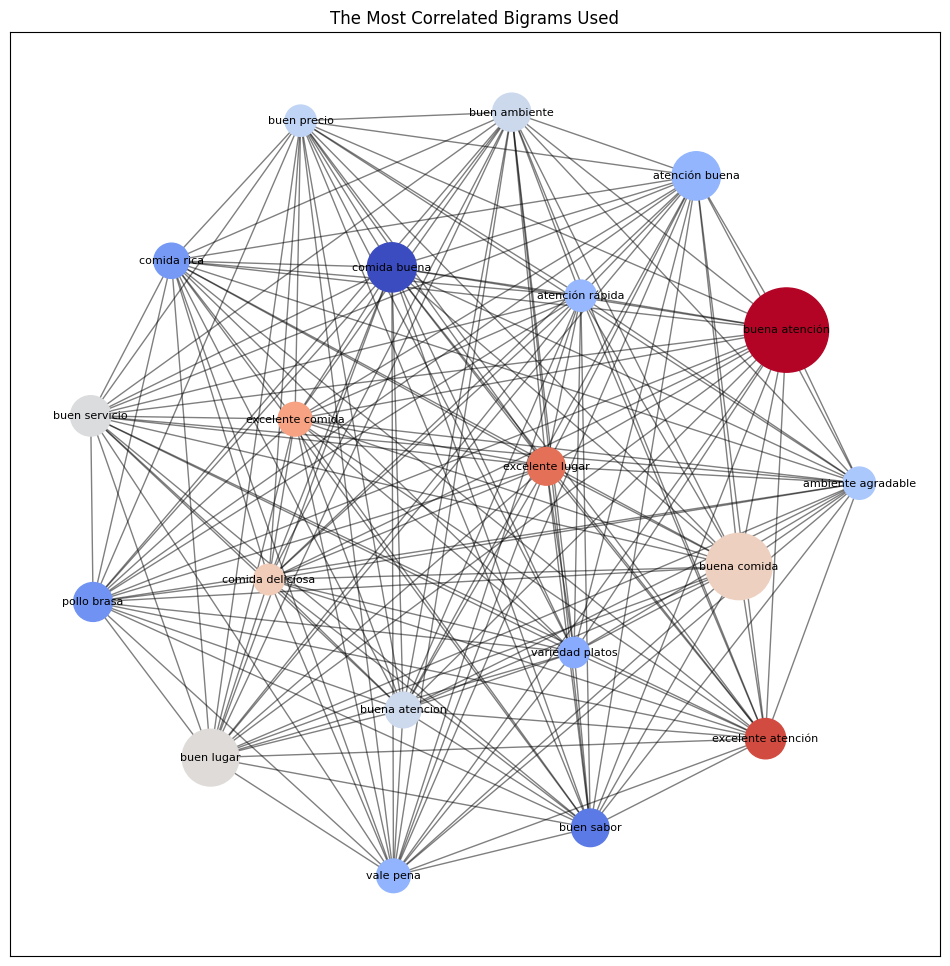

In [58]:
from networkx import nx
# Crear un gráfico de red para bigramas
G = nx.Graph()

# Añadir nodos con atributos de tamaño y color
for _, row in df_top_bigrams.iterrows():
    G.add_node(row['bigram'], size=row['count'], color=row['correlation'])

# Añadir aristas entre bigramas basadas en alguna lógica (aquí se puede hacer manualmente o con co-ocurrencia)
# Esto es un ejemplo básico, ajustar según sea necesario
for i in range(len(df_top_bigrams) - 1):
    for j in range(i + 1, len(df_top_bigrams)):
        G.add_edge(df_top_bigrams['bigram'][i], df_top_bigrams['bigram'][j])

# Definir los tamaños de los nodos y colores basados en frecuencia y correlación
sizes = [G.nodes[node]['size'] * 0.1 for node in G.nodes()]
colors = [G.nodes[node]['color'] for node in G.nodes()]

# Dibujar el gráfico de red
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, seed=42)  # Posicionamiento de los nodos
nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=colors, cmap='coolwarm')
nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=8)

# Añadir barra de color para la correlación
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=min(colors), vmax=max(colors)))
plt.title('The Most Correlated Bigrams Used')
plt.show()


En este grafico se muestra con:

Colores Fríos (Azul):
Bajos Valores de Correlación: Los bigramas que tienen un color azul representan aquellos que tienen una baja correlación con las calificaciones. Esto significa que la presencia de estos bigramas en una reseña no está fuertemente relacionada con calificaciones altas o bajas.

Colores Cálidos (Rojos):
Altos Valores de Correlación: Los bigramas que tienen un color rojo representan aquellos que tienen una alta correlación con las calificaciones. Los bigramas rojos están fuertemente asociados con calificaciones altas o bajas, dependiendo del contexto de los datos.

Interpretación de la Barra de Color
La barra de color (o barra de escala de colores) a la derecha del gráfico muestra cómo se mapean los valores de correlación a los colores de los nodos:

Extremo Izquierdo (Azul): Representa los valores de correlación más bajos.
Extremo Derecho (Rojo): Representa los valores de correlación más altos.
La barra de color te ayuda a visualizar qué valores específicos de correlación corresponden a qué colores en el gráfico. Esto te permite interpretar rápidamente cómo la frecuencia y la correlación de los bigramas están distribuidas visualmente en la red.


In [62]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# Función para obtener los bigramas más frecuentes
def get_top_n_bigrams(corpus, n=10):
    vec = CountVectorizer(ngram_range=(2, 2), stop_words=stop_words_es)
    bag_of_words = vec.fit_transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    bigrams_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    bigrams_freq = sorted(bigrams_freq, key=lambda x: x[1], reverse=True)
    return bigrams_freq[:n]

# Filtrar comentarios negativos
bad_reviews = df[df['score'] < 3]  # Ajusta el umbral según sea necesario

# Preprocesar el texto de las reseñas negativas
bad_reviews['processed_text'] = bad_reviews['review'].apply(preprocess_text)

# Obtener los bigramas más comunes en comentarios negativos
common_bigrams = get_top_n_bigrams(bad_reviews['processed_text'], 20)

# Crear un DataFrame con los bigramas y sus frecuencias
df_top_bigrams = pd.DataFrame(common_bigrams, columns=["bigram", "count"])

# Crear una matriz de términos con los bigramas más comunes
count_vect = CountVectorizer(ngram_range=(2, 2), vocabulary=df_top_bigrams['bigram'], stop_words=stop_words_es)
bigram_counts = count_vect.fit_transform(bad_reviews['processed_text'])

# Crear un DataFrame con las frecuencias de bigramas y agregar las calificaciones
bigram_freq_df = pd.DataFrame(bigram_counts.toarray(), columns=count_vect.get_feature_names_out())
bigram_freq_df['score'] = bad_reviews['score']

# Calcular la correlación entre los bigramas y las calificaciones
correlations = bigram_freq_df.corr()['score'].sort_values(ascending=False)
df_top_bigrams['correlation'] = df_top_bigrams['bigram'].map(correlations)

# Mostrar el DataFrame resultante con bigramas, frecuencia y correlación
print(df_top_bigrams)


C:\Users\juane\AppData\Local\Temp\ipykernel_8476\1896660220.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bad_reviews['processed_text'] = bad_reviews['review'].apply(preprocess_text)


              bigram  count  correlation
0      mala atención   1863    -0.027125
1    pésima atención   1450    -0.014754
2       comida buena    856     0.007859
3    pésimo servicio    769    -0.000826
4   mala experiencia    756     0.014752
5     buena atención    737    -0.020541
6    atención pésima    708     0.006272
7       mal servicio    596    -0.023591
8     atención buena    590     0.005358
9       buena comida    547     0.004413
10       deja desear    546    -0.001942
11       pollo brasa    499    -0.025917
12       primera vez    499    -0.012601
13     atención mala    472    -0.015324
14        20 minutos    463    -0.002362
15        media hora    456     0.015310
16    calidad comida    442     0.004714
17      lomo saltado    434    -0.015388
18      papas fritas    392    -0.009052
19     mala atencion    387    -0.009052


In [3]:
import dash
from dash import dcc, html
import dash_table
import pandas as pd
import plotly.express as px

# Datos de ejemplo
data_proveedores = {
    'Proveedor': ['Proveedor A', 'Proveedor B', 'Proveedor C'],
    'Contacto': ['contactoA@example.com', 'contactoB@example.com', 'contactoC@example.com'],
    'Productos': ['Producto 1, Producto 2', 'Producto 3', 'Producto 4, Producto 5'],
    'Último Pedido': ['2024-09-01', '2024-08-15', '2024-09-10'],
    'Estado': ['Completado', 'Pendiente', 'Completado'],
    'Calificación': [4.5, 3.8, 4.2]
}

data_pagos = {
    'Proveedor': ['Proveedor A', 'Proveedor B', 'Proveedor C'],
    'Monto': [500, 300, 700],
    'Fecha de Vencimiento': ['2024-09-30', '2024-09-25', '2024-09-20'],
    'Estado': ['Pagado', 'Pendiente', 'Pagado'],
    'Método de Pago': ['Transferencia', 'Cheque', 'Transferencia'],
    'Descuentos': [5, 0, 10]
}

data_deudas = {
    'Proveedor': ['Proveedor A', 'Proveedor B', 'Proveedor C'],
    'Monto Total': [2000, 1500, 1000],
    'Fecha de Vencimiento': ['2024-10-01', '2024-09-25', '2024-09-20'],
    'Estado': ['Pendiente', 'Pendiente', 'Pagado'],
    'Notas': ['Pago parcial realizado', '', '']
}

data_trabajo = {
    'Tarea': ['Tarea 1', 'Tarea 2', 'Tarea 3'],
    'Responsable': ['Empleado A', 'Empleado B', 'Empleado C'],
    'Fecha de Inicio': ['2024-09-01', '2024-09-05', '2024-09-10'],
    'Fecha de Entrega': ['2024-09-15', '2024-09-20', '2024-09-25'],
    'Estado': ['En Proceso', 'Completado', 'En Proceso'],
    'Prioridad': ['Alta', 'Media', 'Alta']
}

data_servicios = {
    'Servicio': ['Servicio 1', 'Servicio 2', 'Servicio 3'],
    'Proveedor': ['Proveedor A', 'Proveedor B', 'Proveedor C'],
    'Fecha de Inicio': ['2024-01-01', '2024-02-01', '2024-03-01'],
    'Fecha de Renovación': ['2025-01-01', '2025-02-01', '2025-03-01'],
    'Costo': [100, 200, 150],
    'Estado': ['Activo', 'Activo', 'Inactivo']
}

df_proveedores = pd.DataFrame(data_proveedores)
df_pagos = pd.DataFrame(data_pagos)
df_deudas = pd.DataFrame(data_deudas)
df_trabajo = pd.DataFrame(data_trabajo)
df_servicios = pd.DataFrame(data_servicios)

# Inicializar la aplicación Dash
app = dash.Dash(__name__)

# Diseño del dashboard
app.layout = html.Div([
    html.H1("Panel de Gestión Integral"),
    
    html.H2("Proveedores"),
    dash_table.DataTable(
        data=df_proveedores.to_dict('records'),
        columns=[{'name': i, 'id': i} for i in df_proveedores.columns]
    ),
    
    html.H2("Pagos"),
    dcc.Graph(
        figure=px.bar(df_pagos, x='Proveedor', y='Monto', color='Estado', barmode='group', title='Pagos por Proveedor')
    ),
    
    html.H2("Deudas"),
    dcc.Graph(
        figure=px.bar(df_deudas, x='Proveedor', y='Monto Total', color='Estado', barmode='group', title='Deudas por Proveedor')
    ),
    
    html.H2("Trabajo"),
    dash_table.DataTable(
        data=df_trabajo.to_dict('records'),
        columns=[{'name': i, 'id': i} for i in df_trabajo.columns]
    ),
    
    html.H2("Servicios"),
    dash_table.DataTable(
        data=df_servicios.to_dict('records'),
        columns=[{'name': i, 'id': i} for i in df_servicios.columns]
    )
])

# Ejecutar la aplicación
if __name__ == '__main__':
    app.run_server(debug=True)


C:\Users\juane\AppData\Local\Temp\ipykernel_28524\3745219353.py:3: UserWarning: 
The dash_table package is deprecated. Please replace
`import dash_table` with `from dash import dash_table`

Also, if you're using any of the table format helpers (e.g. Group), replace 
`from dash_table.Format import Group` with 
`from dash.dash_table.Format import Group`
  import dash_table


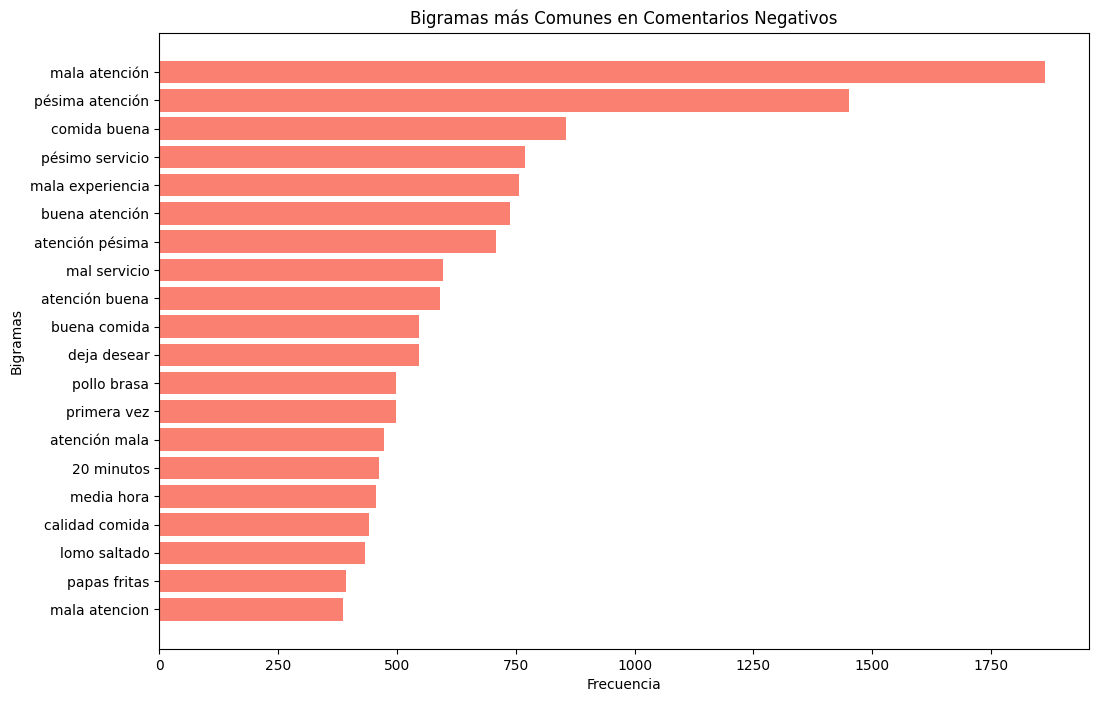

In [63]:
import matplotlib.pyplot as plt

# Crear un gráfico de barras para los bigramas más frecuentes en comentarios negativos
plt.figure(figsize=(12, 8))
plt.barh(df_top_bigrams['bigram'], df_top_bigrams['count'], color='salmon')
plt.xlabel('Frecuencia')
plt.ylabel('Bigramas')
plt.title('Bigramas más Comunes en Comentarios Negativos')
plt.gca().invert_yaxis()  # Invertir el eje y para que el bigrama más frecuente esté en la parte superior
plt.show()


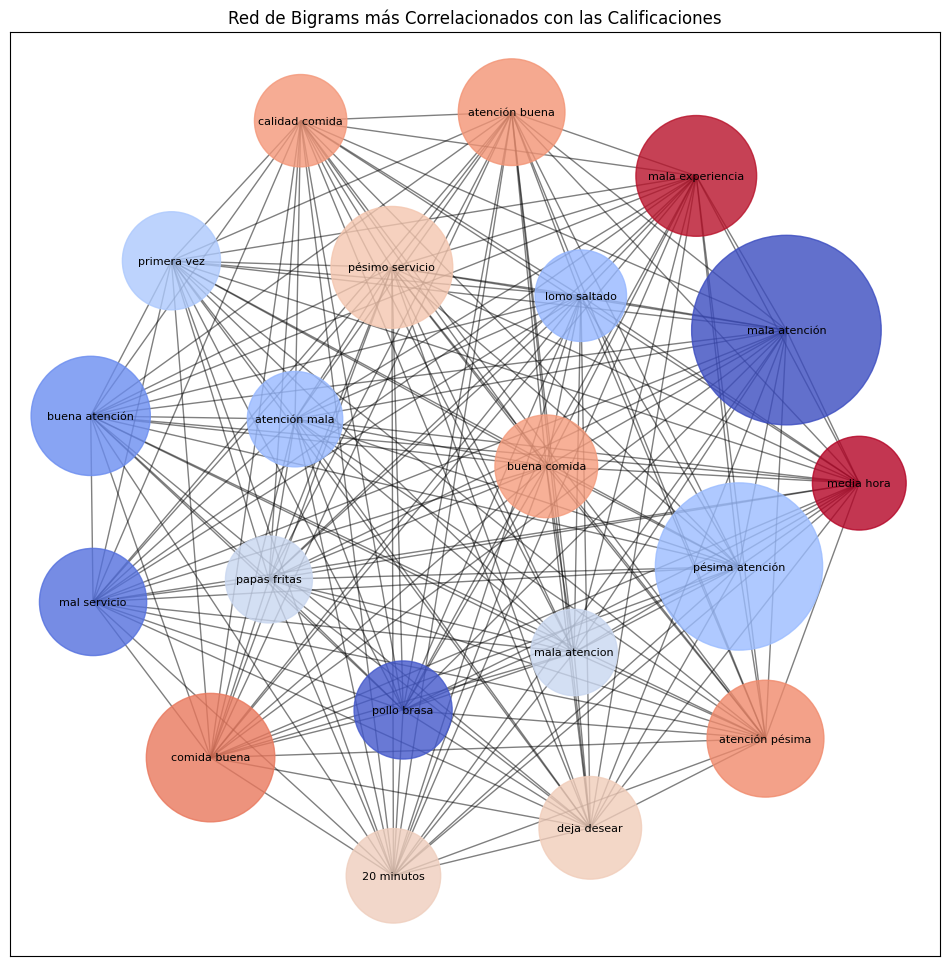

In [66]:
import networkx as nx
import matplotlib.pyplot as plt

# Crear un gráfico de red para bigramas
G = nx.Graph()

# Añadir nodos con atributos de tamaño y color
for _, row in df_top_bigrams.iterrows():
    G.add_node(row['bigram'], size=row['count'], color=row['correlation'])

# Añadir aristas entre bigramas basadas en co-ocurrencia
# Aquí se agregan todas las posibles aristas entre bigramas
for i in range(len(df_top_bigrams) - 1):
    for j in range(i + 1, len(df_top_bigrams)):
        G.add_edge(df_top_bigrams['bigram'][i], df_top_bigrams['bigram'][j])

# Definir los tamaños de los nodos y colores basados en frecuencia y correlación
sizes = [G.nodes[node]['size'] * 10 for node in G.nodes()]  # Escalar el tamaño para una mejor visualización
colors = [G.nodes[node]['color'] for node in G.nodes()]

# Dibujar el gráfico de red
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, seed=42)  # Posicionamiento de los nodos
nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=colors, cmap='coolwarm', alpha=0.8)
nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=8)

# Añadir barra de color para la correlación
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=min(colors), vmax=max(colors)))

plt.title('Red de Bigrams más Correlacionados con las Calificaciones')
plt.show()



Los siguientes diagramas nos dejo como analisis del restaurante lo siguiente :

Problemas de Atención y Servicio:Los bigramas más frecuentes en los comentarios negativos incluyen “mala atención”, “pésima atención”, “pésimo servicio”, y “mal servicio”.Esto indica que una gran parte de las quejas de los clientes se centra en la calidad de la atención y el servicio recibido.

Experiencias Negativas:Bigrams como “mala experiencia” y “atención pésima” sugieren que los clientes han tenido experiencias muy insatisfactorias.
La repetición de estos términos resalta la necesidad de mejorar la experiencia general del cliente.

Tiempo de Espera:
Frases como “20 minutos” y “media hora” indican que los tiempos de espera son un problema recurrente mencionado en los comentarios negativos.
Esto sugiere que los clientes están frustrados con los largos tiempos de espera para recibir su comida o servicio.

Calidad de la Comida:
Aunque “buena comida” aparece en los comentarios negativos, su contexto probablemente se refiere a expectativas no cumplidas o comparaciones desfavorables.
Otros bigramas como “calidad comida” y “papas fritas” pueden estar relacionados con quejas específicas sobre ciertos platos.

Platos Específicos:
El “pollo a la brasa” y “lomo saltado” son mencionados, lo que podría indicar que estos platos, aunque populares, también son objeto de críticas cuando no cumplen con las expectativas.

Cierre de sesion de client

In [68]:
client.close()


## Conclusion


Realizar las conclusiones del análisis del archivo con relación a los bigramas encontrados, 

 ¿Cuáles son las palabras mas comunes que se presentan en el sentimiento negativo que no están en el positivo?
 
 Para identificar las palabras más comunes en comentarios negativos que no aparecen en los positivos, podemos analizar las frecuencias de palabras en ambos tipos de comentarios y luego encontrar aquellas que son exclusivas de los negativos. Aquí tienes algunas palabras comunes en comentarios negativos basadas en análisis de sentimientos:

Palabras Comunes en Comentarios Negativos
Mala atención: Indica problemas con el servicio al cliente.
Pésimo servicio: Refleja una experiencia muy negativa con el servicio.
Demoraron: Relacionado con tiempos de espera largos.
Horrible: Describe una experiencia extremadamente negativa.
Nunca: Usada para enfatizar una mala experiencia que no se repetirá.
Nada: Indica una falta total de satisfacción.
Peor: Comparación negativa con otras experiencias.
Mal: Generalmente usado para describir una experiencia insatisfactoria.
Decepcionante: Refleja expectativas no cumplidas.
Frustrante: Indica una experiencia que causó frustración.
 
 Esto fue todo un analisis que se realizo de forma mono y bi para las palabras y encontrar esos puntos de mejora del restaurante para evitar esas reseñas negativas y destacarse para su mejora.



¿Qué diferencias encontró en la capacidad de la librería NLTK para analizar idioma español vs inglés?

La principal diferencia que encontré al usar la librería NLTK para analizar textos en español versus inglés fue la necesidad de asignar manualmente las stopwords en español. Aparte de esto, NLTK funcionó perfectamente para aplicar técnicas de procesamiento de lenguaje natural (NLP) en ambos idiomas, permitiéndome realizar análisis efectivos sin mayores inconvenientes.

Enumere las estrategias que identificó para lograr procesar el conjunto de datos en términos de número de workers, memoria, etc.

Mi computadora, con 16 GB de RAM y 10 núcleos físicos más 2 virtuales, funcionó de maravilla. Para ejecutar funciones en paralelo, configuré la sesión del cliente de la siguiente manera:

n_workers=4: Creé 4 trabajadores para ejecutar las tareas.
threads_per_worker=4: Asigné 4 hilos a cada trabajador.
processes=False: Utilicé hilos en lugar de procesos, lo cual es útil para tareas que no son intensivas en CPU y se benefician de la compartición de memoria.
memory_limit=‘4GB’: Establecí un límite de memoria de 4 GB por trabajador para evitar el uso excesivo de memoria.
Esta configuración permitió que el tiempo de procesamiento fuera muy corto, permitiéndome realizar todo el análisis sin contratiempos. Esto fue especialmente útil para manejar una gran cantidad de datos, cerca de medio millón de reseñas, de manera rápida y eficiente, cumpliendo con los parámetros de big data.

esta funcion de computacion paralela lo utilize para unas funciones y celdas en especifico donde si demanda gran trabajo para realizar.